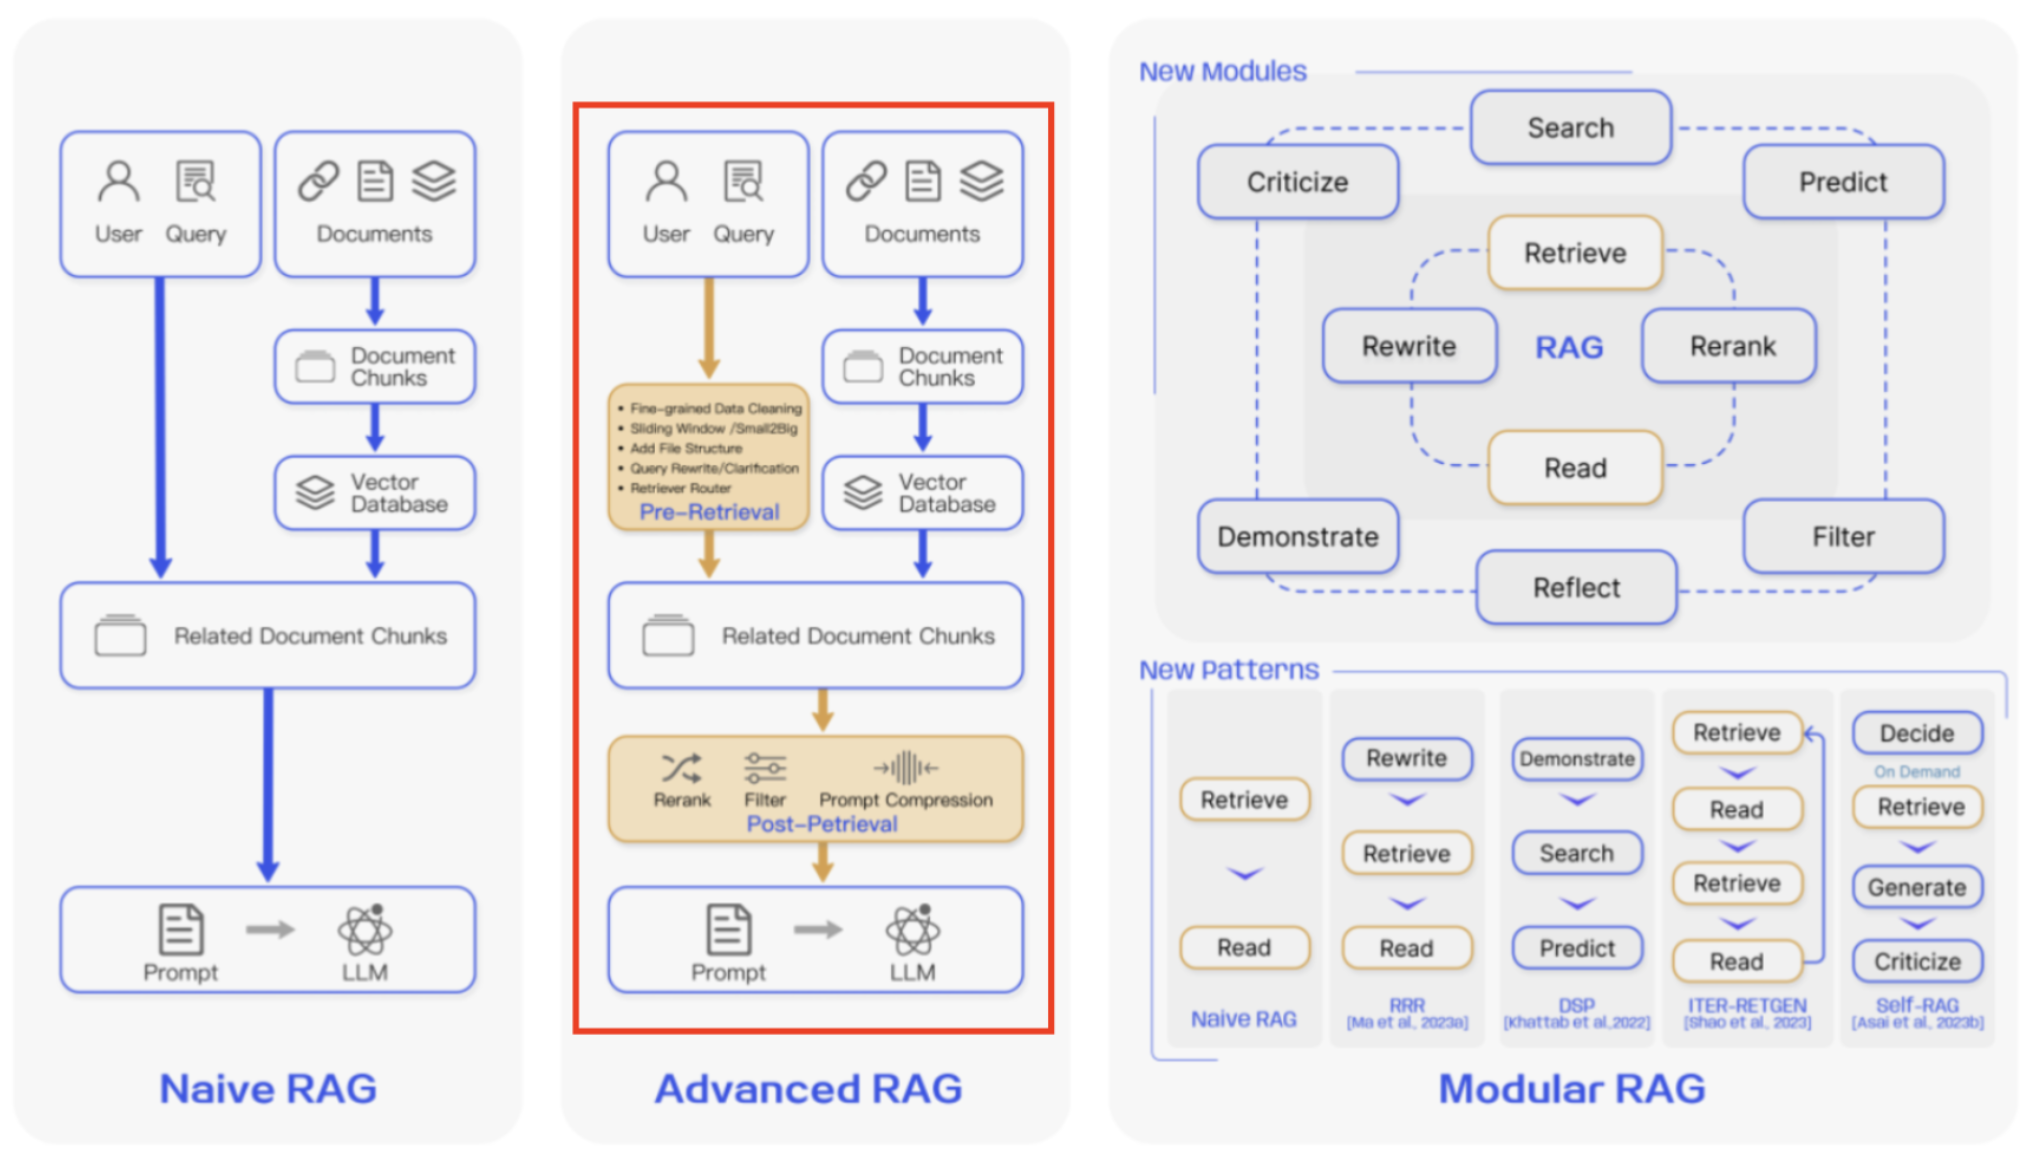

# [Milvus 벡터 데이터베이스](https://milvus.io/ko/intro)


## 1. Milvus란?
> Milvus는 오픈소스 벡터 데이터베이스로, 대규모 벡터 검색과 머신러닝 애플리케이션을 위한 고성능 데이터 저장소입니다.

### 주요 특징
- **고성능**: 밀리초 단위의 벡터 검색 성능
- **확장성**: 수십억 개의 벡터를 처리할 수 있는 수평적 확장
- **다양한 인덱스**: IVF, HNSW, ANNOY 등 다양한 벡터 인덱스 지원
- **클라우드 네이티브**: Kubernetes 환경에서 완벽하게 동작
- **다양한 API**: RESTful API, Python SDK, Java SDK 등 제공


### [RAG에서의 활용](https://milvus.io/ko/bootcamp)
- 문서 임베딩 벡터 저장
- 의미 기반 유사 문서 검색
- 하이브리드 검색 (벡터 + 키워드)
- 멀티모달 검색 지원

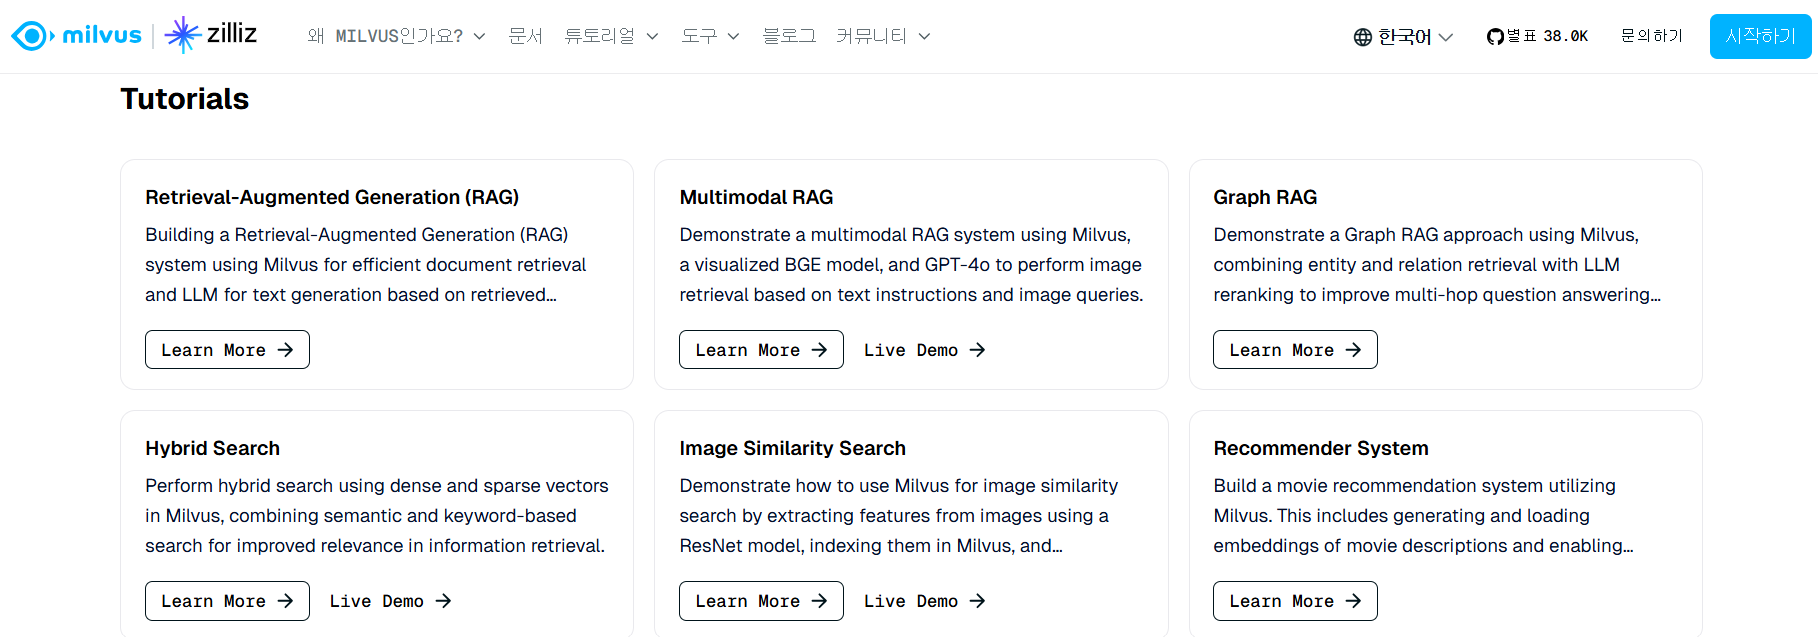

### Milvus는 어떻게 작동하나요?
> Milvus는 벡터 데이터를 효율적으로 처리하고 확장성, 조정 가능성 및 데이터 격리를 보장하기 위해 설계된 다층 아키텍처를 중심으로 구축되었습니다.

- 액세스 계층
    - 이 계층은 외부 요청의 최초 접점 역할을 하며 스테이트리스 프록시를 사용하여 클라이언트 연결 관리, 정적 검증 및 동적 검사를 수행합니다. 이러한 프록시는 또한 로드 밸런싱을 처리하며 Milvus의 포괄적인 API 스위트를 구현하는 데 중요합니다. 다운스트림 서비스가 요청을 처리한 후 액세스 계층은 응답을 사용자에게 라우팅합니다.

- 코디네이터 서비스
    - 중앙 명령으로 작동하여 4개의 코디네이터를 통해 로드 밸런싱 및 데이터 관리를 조정합니다. 이를 통해 데이터, 쿼리 및 인덱스의 효율적인 관리가 가능합니다.

- 워커 노드
    - 실제 작업 실행을 담당하며 코디네이터의 명령을 실행하는 확장 가능한 포드입니다. 이를 통해 Milvus는 변화하는 데이터, 쿼리 및 인덱싱 요구에 동적으로 조정하여 시스템의 확장성과 조정 가능성을 지원합니다.

- 객체 스토리지 계층: 데이터 지속성에 필수적이며 다음 요소로 구성됩니다.
    - Meta store: 메타데이터 스냅샷 및 시스템 상태 확인을 위해 etcd 사용합니다.
    - Log broker: Pulsar 또는 RocksDB를 활용하여 스트리밍 데이터 지속성 및 복구를 위해 사용합니다.
    - Object storage: AWS S3, Azure Blob Storage, MinIO와 같은 서비스를 지원하여 로그 스냅샷, 인덱스 파일 및 쿼리 결과를 저장합니다.

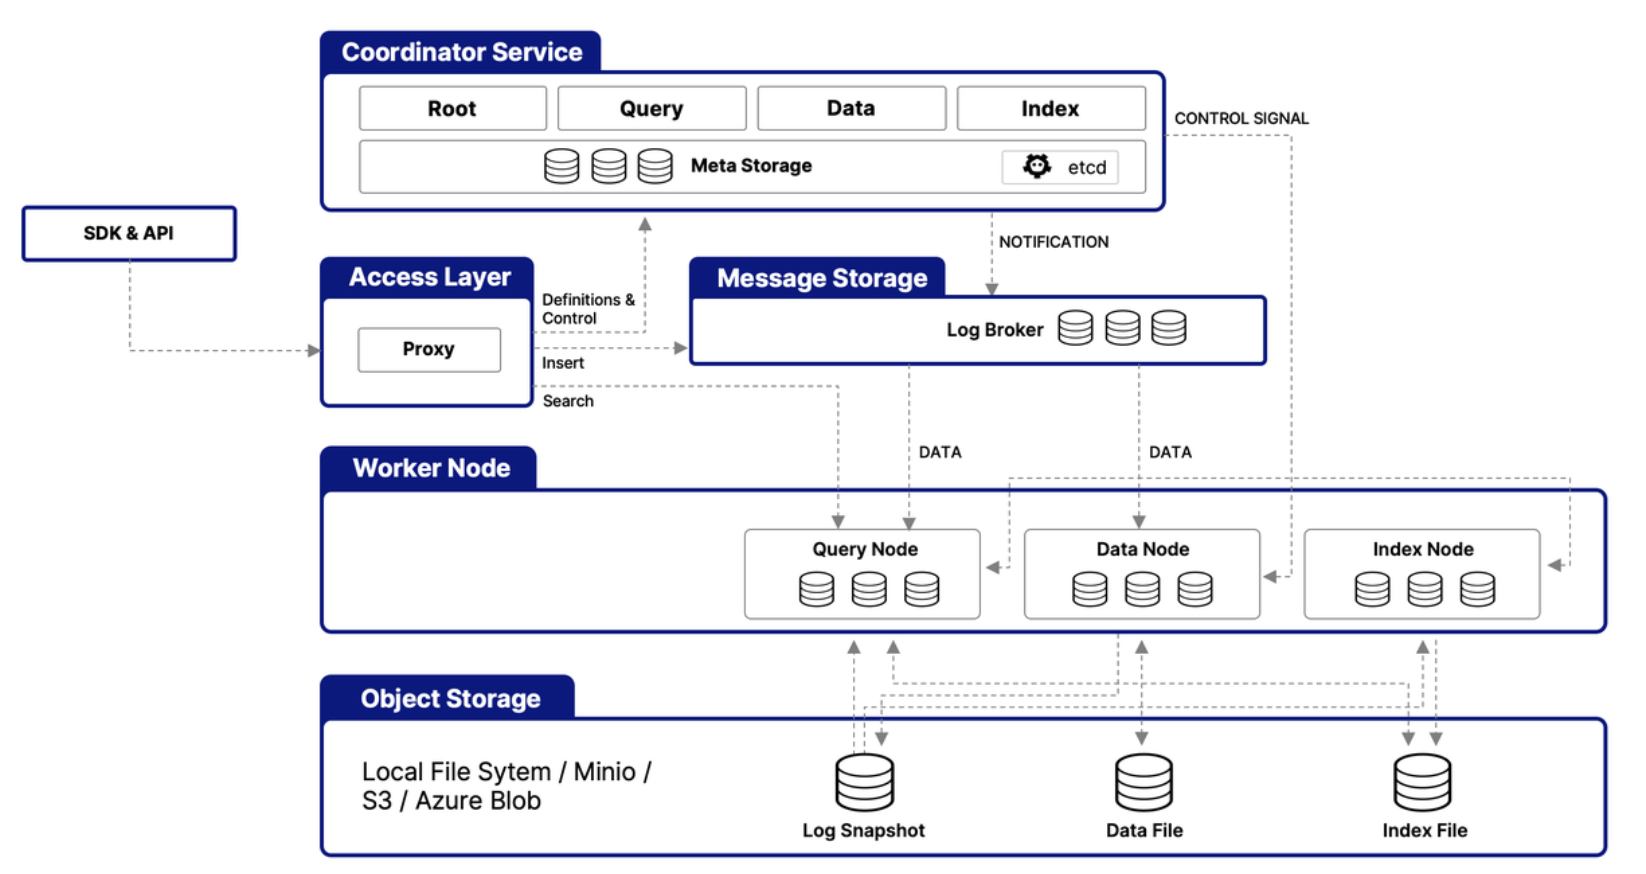

## 2. Milvus 설치 및 확인


### 2.2 MinIO 웹 콘솔
Milvus 자체가 대규모 파일 저장소가 아니기 때문에, 이러한 대용량 데이터는 외부 스토리지 시스템에 맡기는 것이 일반적입니다. 여기서 MinIO가 역할을 합니다.
- Milvus = 벡터 검색 엔진    
- MinIO = Milvus가 벡터 데이터를 저장하는 S3 호환 스토리지

[MinIO 웹 콘솔](http://localhost:9001)
> ID: minioadmin / PW: minioadmin

```url
http://localhost:9001
```

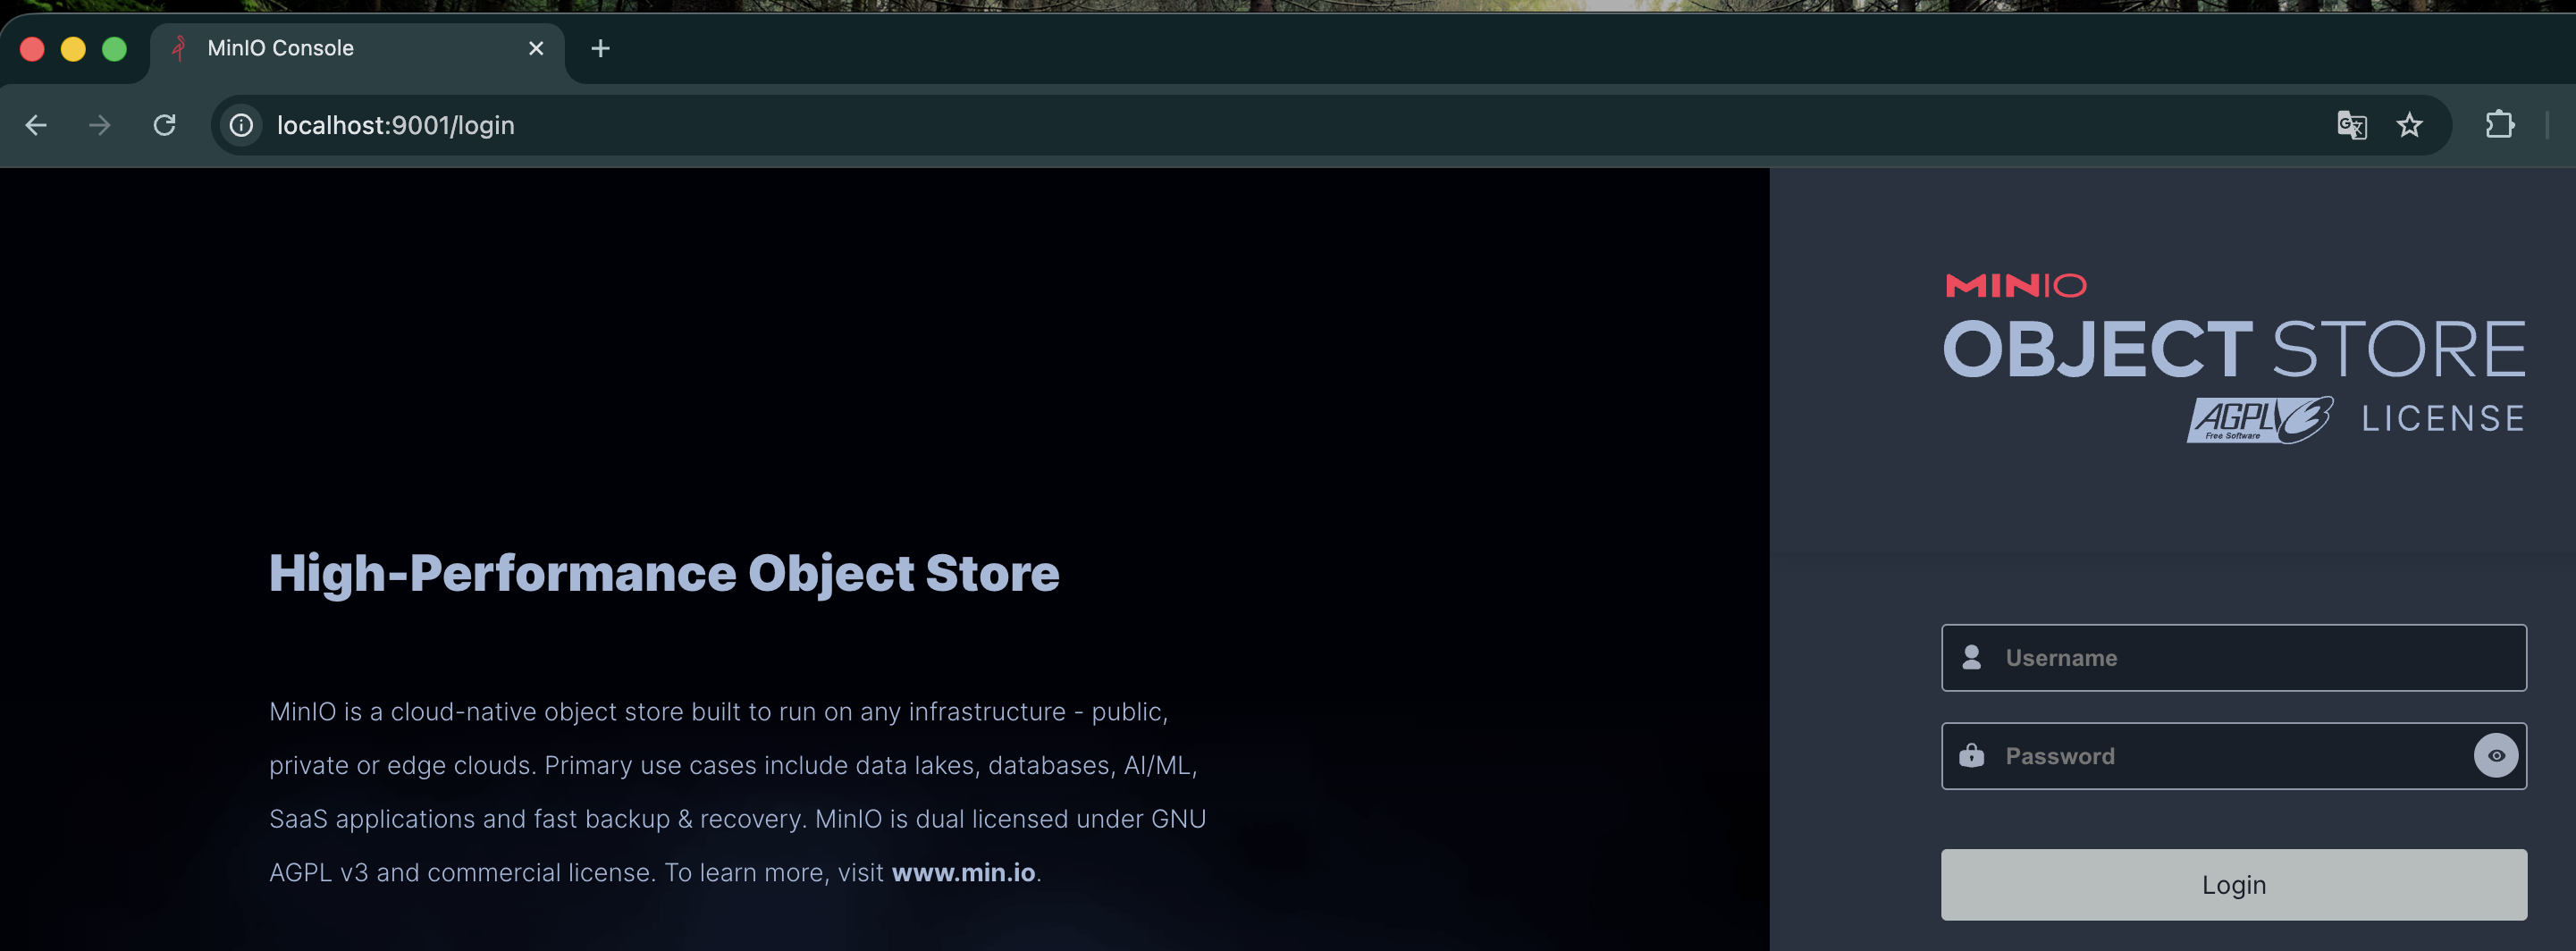

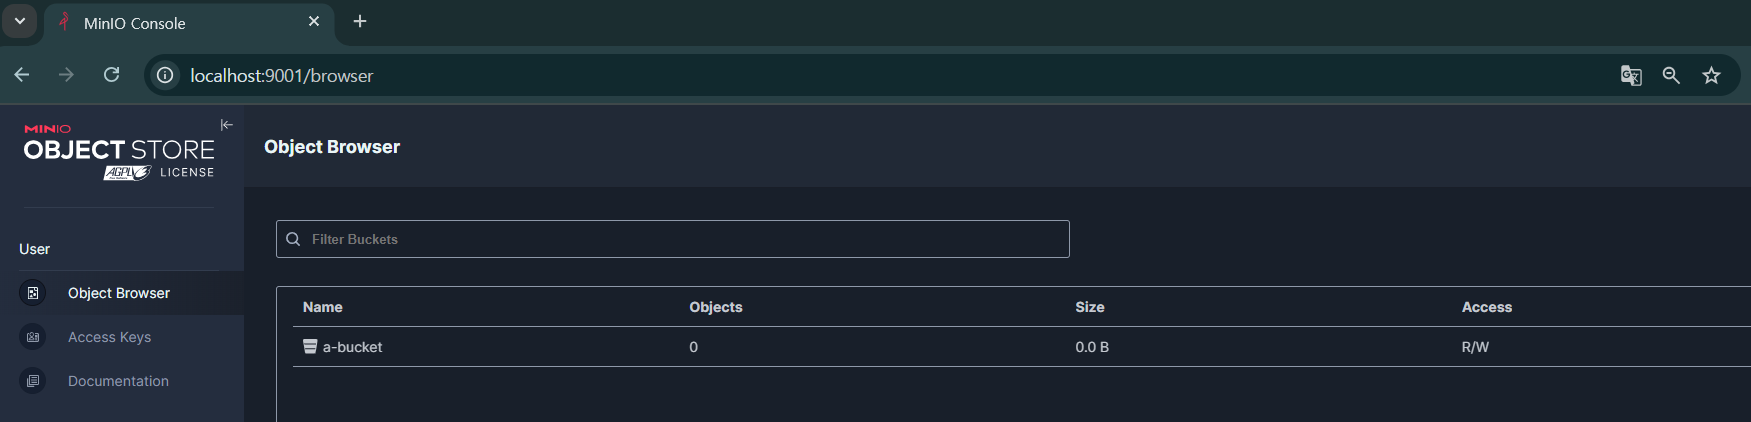

### [2.3 Attu (Milvus 관리용 Web UI)](http://localhost:8000)
```url
http://localhost:8000
```

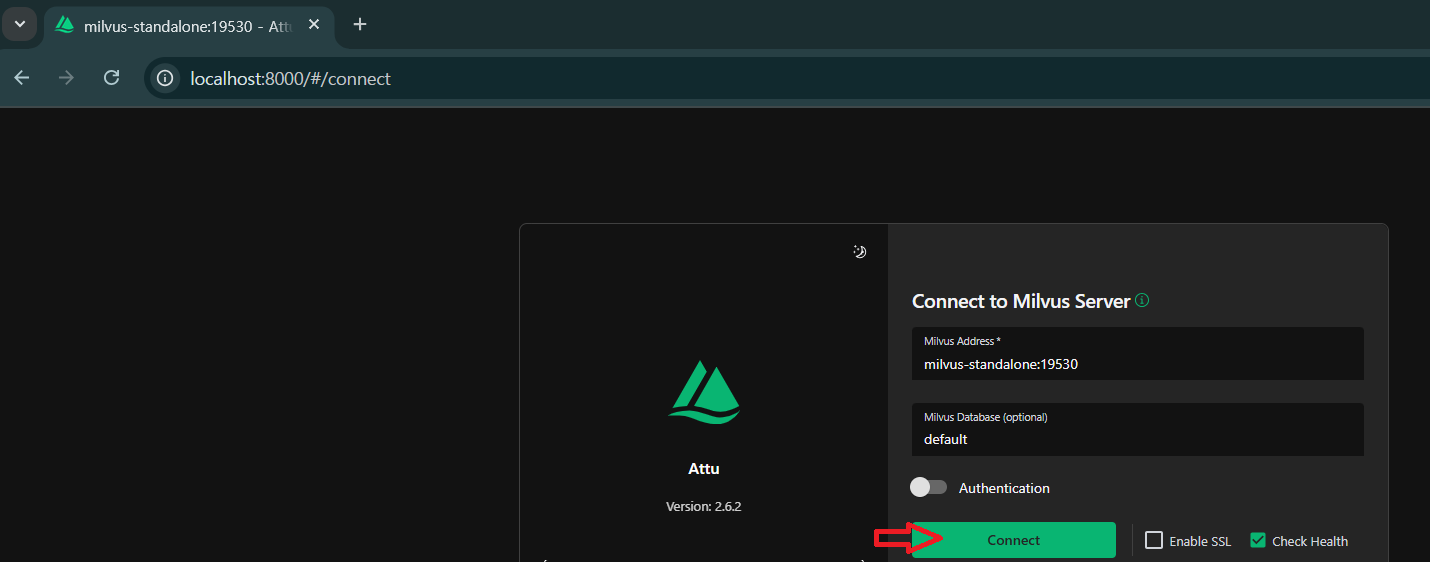

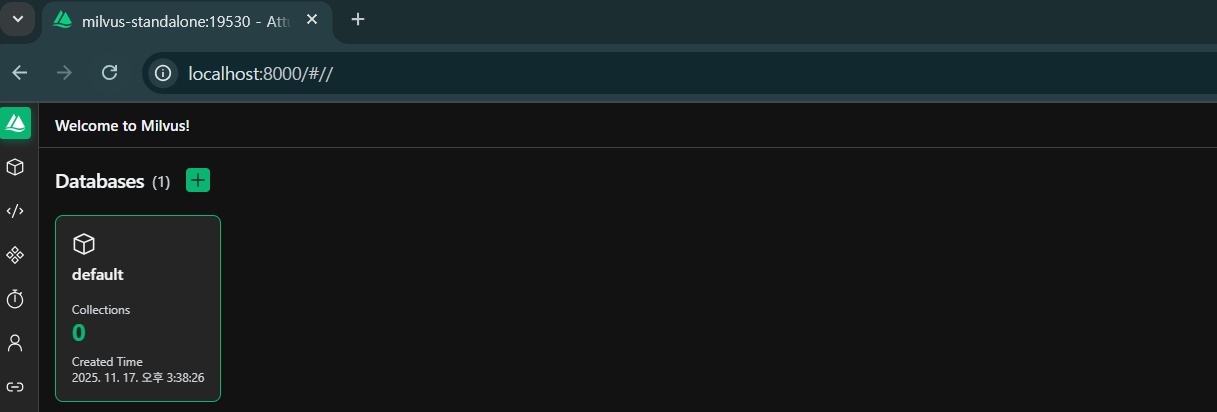

## 3. 기본 Milvus 사용법

### 3.1 연결 설정


> 인증 정보 확인

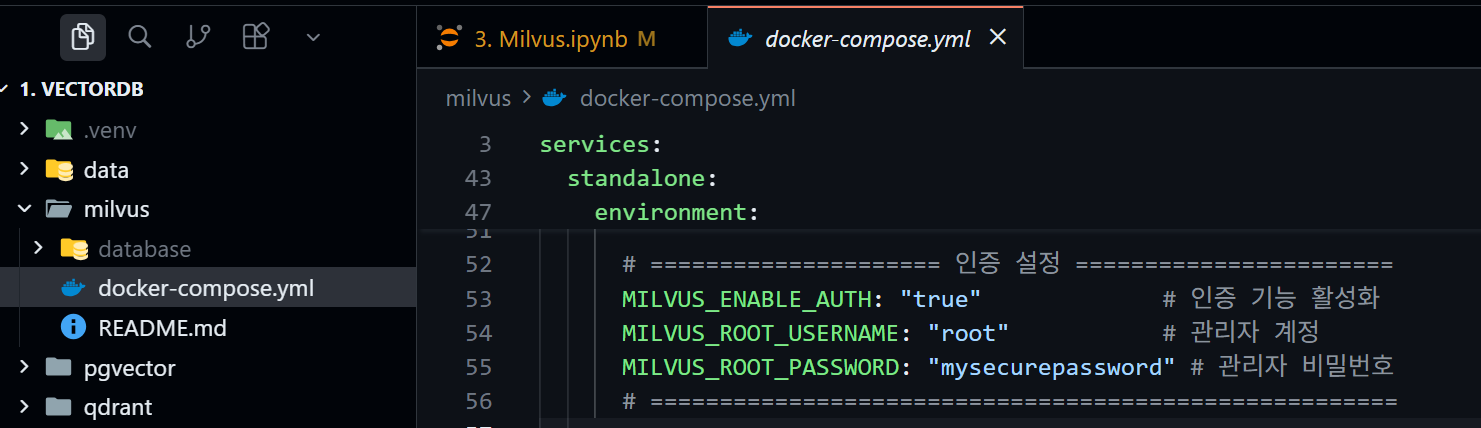

In [1]:
from pymilvus import connections

# Milvus 데이터베이스에 연결
# connections.connect()는 Milvus 서버와의 연결을 설정하는 함수
connections.connect(
    alias="milvus_dev",           # 연결 이름(별칭) - 여러 Milvus 서버를 사용할 때 구분하기 위한 식별자
    host="localhost",             # Milvus 서버 주소 (Docker 컨테이너가 localhost에서 실행 중)
    port="19530",                 # Milvus의 gRPC 통신 포트 (기본값: 19530)
    user="root",                  # Milvus 관리자 계정 (인증이 활성화된 경우 필수)
    password="mysecurepassword"   # Milvus 비밀번호 (인증이 활성화된 경우 필수)
)

print("Milvus 연결 성공!")


Milvus 연결 성공!


### 3.2 컬렉션 생성
> connections을 통해 Milvus 연결 후 컬렉션 생성 가능 

In [2]:
from pymilvus import Collection, CollectionSchema, FieldSchema, DataType, utility

# Milvus 컬렉션(테이블 개념) 생성 함수
# Collection: 데이터베이스의 테이블과 유사한 개념으로, 벡터와 메타데이터를 저장
def create_collection():
    collection_name = "document_embeddings"
    
    # 기존에 동일한 이름의 컬렉션이 존재하는지 확인하고, 있으면 삭제
    # 중복 방지 및 깨끗한 상태에서 시작하기 위함
    if utility.has_collection(collection_name, using="milvus_dev"):
        utility.drop_collection(collection_name, using="milvus_dev")
        print(f"기존 컬렉션 '{collection_name}' 삭제 완료")
    
    # 컬렉션의 필드(열) 정의
    # 각 필드는 데이터베이스의 컬럼과 유사한 개념
    fields = [
        # id 필드: 각 문서의 고유 식별자 (Primary Key)
        # auto_id=True: 자동으로 ID 생성
        FieldSchema(name="id", dtype=DataType.INT64, is_primary=True, auto_id=True),
        
        # text 필드: 원본 텍스트를 저장하는 필드
        # max_length: 저장 가능한 최대 문자 길이
        FieldSchema(name="text", dtype=DataType.VARCHAR, max_length=1000),
        
        # embedding 필드: 텍스트의 벡터 임베딩을 저장
        # dim=1024: 벡터의 차원 수 (사용하는 임베딩 모델에 따라 달라짐)
        # qwen3-embedding:0.6b 모델은 1024차원의 벡터를 생성
        FieldSchema(name="embedding", dtype=DataType.FLOAT_VECTOR, dim=1024)  
    ]
    
    # 스키마 생성: 필드들을 모아서 하나의 스키마(구조)로 정의
    # 두 번째 인자는 컬렉션에 대한 설명(description)
    schema = CollectionSchema(fields, "문서 임베딩을 위한 컬렉션")
    
    # 정의된 스키마를 바탕으로 실제 컬렉션 생성
    collection = Collection(
        name=collection_name,   # 컬렉션 이름
        schema=schema,          # 위에서 정의한 스키마
        using="milvus_dev"      # 사용할 Milvus 연결 (앞서 정의한 connections의 alias)
    )
    
    return collection


In [3]:
# 컬렉션 생성
collection = create_collection()
print(f"컬렉션 '{collection.name}' 생성 완료")


컬렉션 'document_embeddings' 생성 완료


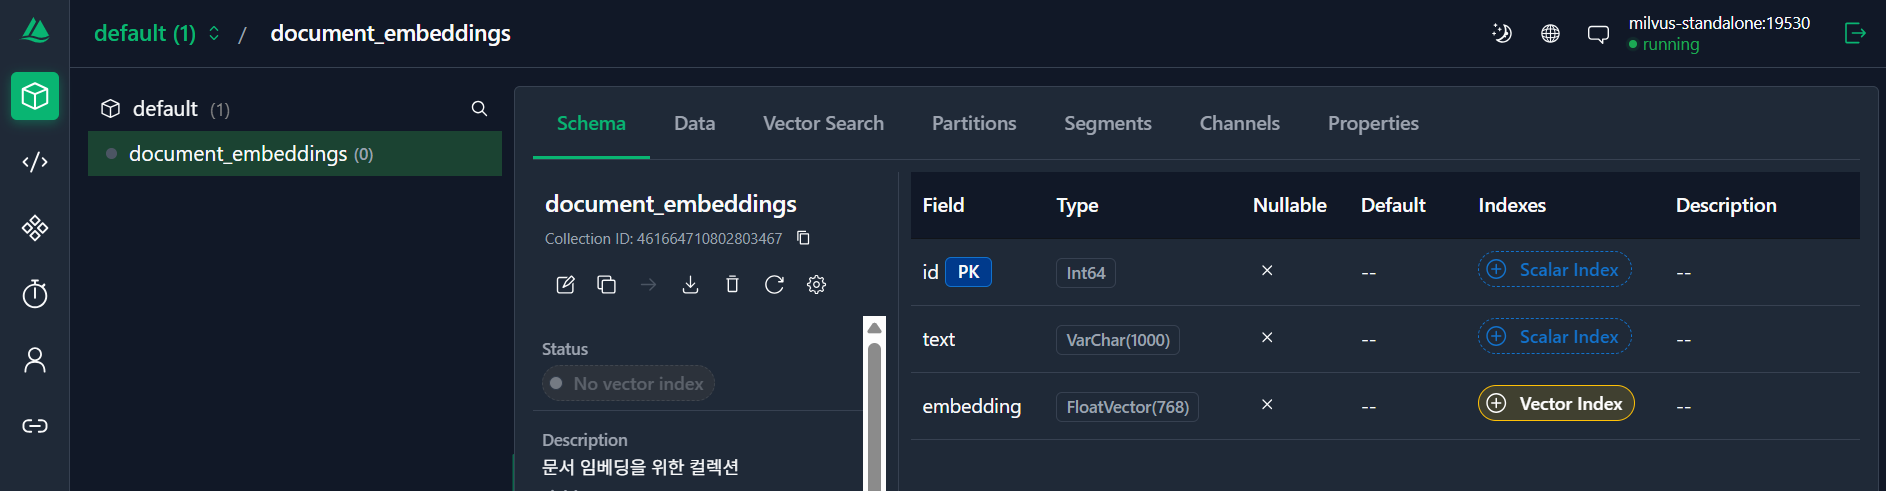

### 3.3 인덱스 생성


In [4]:
# 벡터 검색 성능을 향상시키기 위한 인덱스 생성 함수
# 인덱스: 데이터베이스에서 검색 속도를 높이기 위한 자료구조
def create_index(collection):
    # IVF_FLAT 인덱스 파라미터 설정
    # IVF (Inverted File Index): 벡터 공간을 여러 클러스터로 나누어 검색 범위를 좁히는 방식
    index_params = {
        # metric_type: 벡터 간 유사도를 측정하는 방식
        # L2 (Euclidean Distance): 두 벡터 간의 직선 거리를 계산
        # 값이 작을수록 더 유사함을 의미
        "metric_type": "L2",
        
        # index_type: 인덱스 알고리즘 종류
        # IVF_FLAT: 정확도가 높은 기본 인덱스 (근사값이 아닌 정확한 거리 계산)
        "index_type": "IVF_FLAT",
        
        # params: 인덱스 관련 추가 파라미터
        # nlist: 벡터 공간을 몇 개의 클러스터로 나눌지 결정
        # 값이 클수록 검색 정확도는 높아지지만 인덱싱 시간이 증가
        "params": {"nlist": 1024}
    }
    
    # embedding 필드에 대해 인덱스 생성
    # 인덱스가 생성되면 벡터 검색이 훨씬 빨라짐
    collection.create_index("embedding", index_params)
    print("인덱스 생성 완료")
    

In [5]:
# 인덱스 생성
create_index(collection)


인덱스 생성 완료


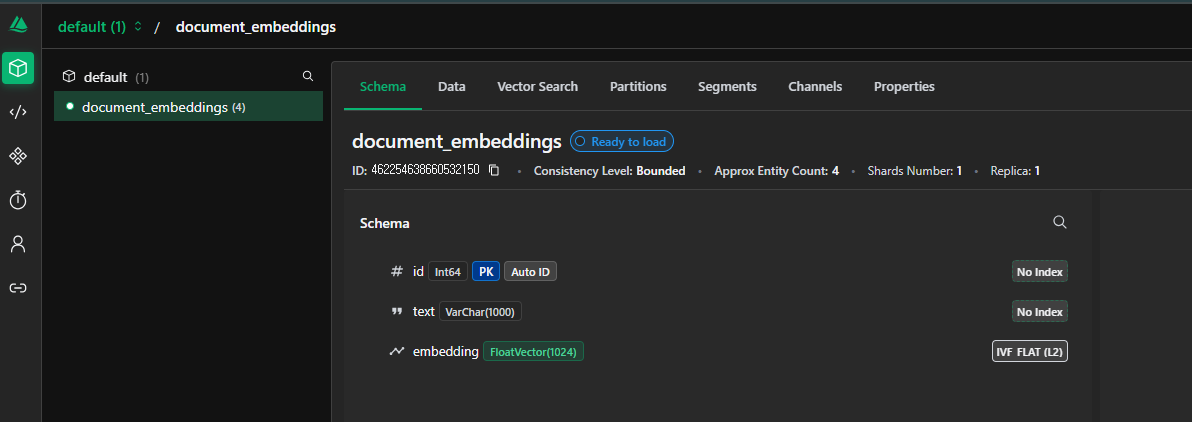

### 3.4 데이터 삽입


In [6]:
from langchain_ollama import OllamaEmbeddings

# Ollama 임베딩 모델 초기화
# OllamaEmbeddings: 로컬에서 실행되는 Ollama를 통해 텍스트를 벡터로 변환
# qwen3-embedding:0.6b: 6억 개의 파라미터를 가진 경량 임베딩 모델
# 이 모델은 1024차원의 벡터를 생성
embeddings_ollama = OllamaEmbeddings(model="qwen3-embedding:0.6b")

In [7]:
# 샘플 텍스트 데이터를 벡터로 변환하여 Milvus에 삽입하는 함수
def insert_data(collection):
    # 삽입할 샘플 텍스트 데이터
    # 실제 RAG 시스템에서는 문서 로더로부터 가져온 텍스트를 사용
    texts = [
        "인공지능은 컴퓨터 과학의 한 분야입니다.",
        "머신러닝은 데이터로부터 패턴을 학습합니다.",
        "딥러닝은 신경망을 사용한 머신러닝입니다.",
        "자연어처리는 컴퓨터가 인간의 언어를 이해하는 기술입니다."
    ]
    
    # 텍스트를 벡터 임베딩으로 변환
    # embed_documents(): 여러 개의 텍스트를 한 번에 임베딩
    # 결과: 각 텍스트에 대응하는 벡터 리스트
    embedding_vectors = embeddings_ollama.embed_documents(texts)
    
    # 디버깅: 생성된 임베딩 벡터의 형태 확인
    print(f"임베딩 벡터 개수: {len(embedding_vectors)}")
    print(f"첫 번째 임베딩 차원: {len(embedding_vectors[0])}")
    
    # Milvus에 삽입할 데이터 준비
    # 리스트 형식으로 각 필드의 값들을 순서대로 전달
    # 주의: 스키마 정의 시 필드 순서와 일치해야 함 (id는 auto_id이므로 제외)
    data = [
        texts,              # text 필드에 저장될 원본 텍스트
        embedding_vectors   # embedding 필드에 저장될 벡터 데이터
    ]
    
    # 데이터를 컬렉션에 삽입
    result = collection.insert(data)
    
    # flush(): 메모리에 있는 데이터를 디스크에 강제로 저장
    # 데이터 손실 방지 및 즉시 검색 가능하도록 함
    collection.flush()
    
    print(f"{len(texts)}개 문서 삽입 완료")
    # primary_keys: 자동 생성된 ID 값들을 확인
    print(f"삽입된 ID: {result.primary_keys}")
    

In [8]:
# 데이터 삽입
insert_data(collection)


임베딩 벡터 개수: 4
첫 번째 임베딩 차원: 1024
4개 문서 삽입 완료
삽입된 ID: [462700432930378752, 462700432930378753, 462700432930378754, 462700432930378755]


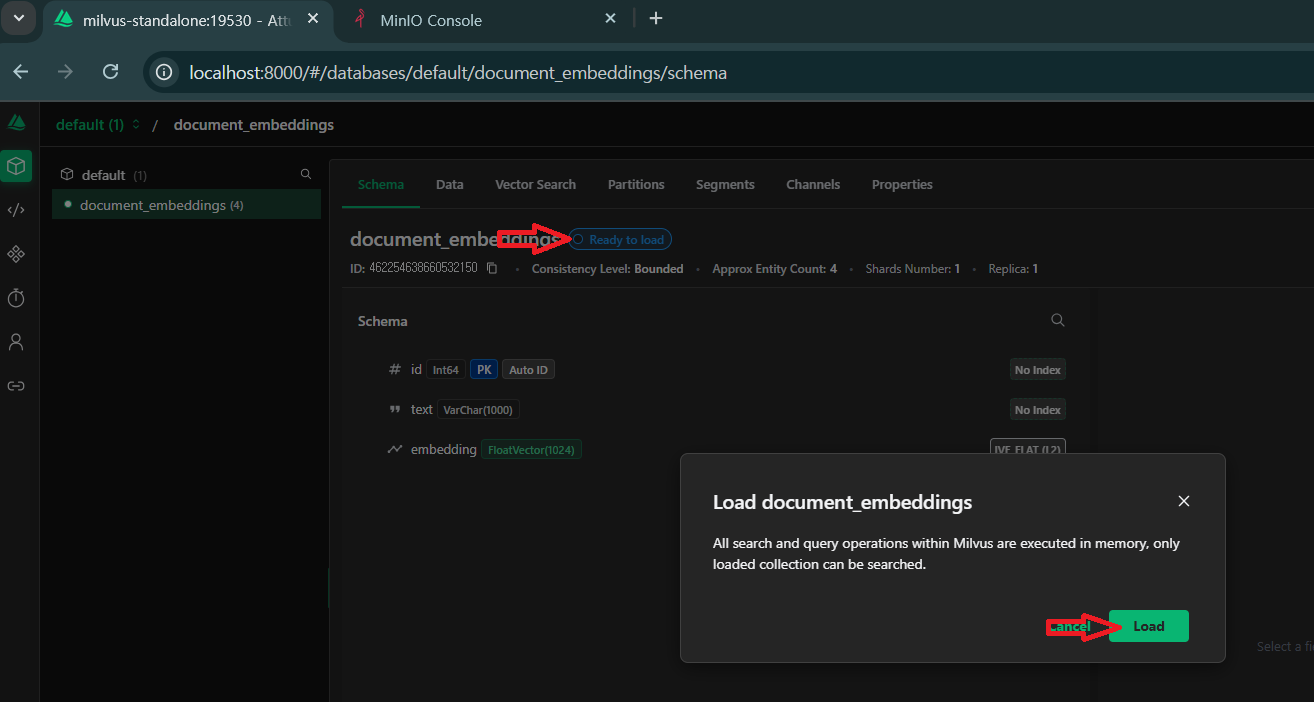

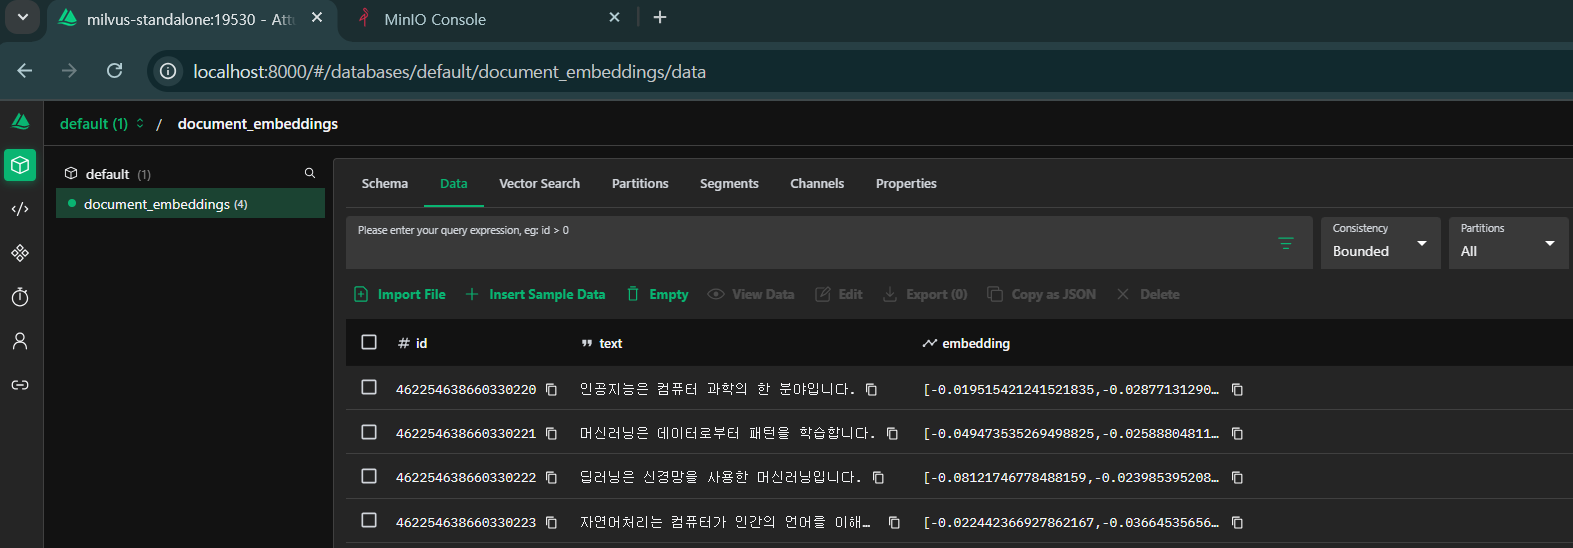

### 3.5 벡터 검색


In [9]:
# 쿼리 벡터와 유사한 벡터를 검색하는 함수
# 벡터 검색(Similarity Search): 주어진 벡터와 가장 가까운(유사한) 벡터들을 찾는 과정
def search_vectors(collection, query_vector, top_k=3):
    # 컬렉션을 메모리에 로드
    # 검색을 수행하기 전에 반드시 컬렉션을 메모리에 로드해야 함
    collection.load()
    
    # 검색 시 사용할 파라미터 설정
    search_params = {
        # metric_type: 벡터 간 거리를 측정하는 방식 (인덱스 생성 시와 동일해야 함)
        "metric_type": "L2",
        
        # nprobe: 검색할 클러스터 수 (IVF 인덱스에서 사용)
        # 값이 클수록 정확도는 높아지지만 검색 속도는 느려짐
        # nlist(1024)의 약 1% 정도인 10을 사용 (속도와 정확도의 균형)
        "params": {"nprobe": 10}
    }
    
    # 벡터 검색 실행
    results = collection.search(
        data=[query_vector],        # 검색 쿼리로 사용할 벡터 (리스트 형태로 전달)
        anns_field="embedding",     # 검색 대상이 되는 벡터 필드명
        param=search_params,        # 위에서 정의한 검색 파라미터
        limit=top_k,                # 반환할 최대 결과 개수 (상위 k개)
        output_fields=["text"]      # 결과와 함께 반환할 필드 (원본 텍스트)
    )
    
    return results


In [10]:
# 사용자 질문을 벡터로 변환
# embed_documents(): 텍스트 리스트를 벡터 리스트로 변환
# 검색 시에는 질문도 동일한 임베딩 모델로 벡터화해야 함
query_vector = embeddings_ollama.embed_documents(["인공지능이란?"])

In [11]:
# 검색 수행
results = search_vectors(collection, query_vector[0], top_k=3)

# 결과 출력
print("검색 결과:")
for i, result in enumerate(results[0]):
    print(f"{i+1}. 거리: {result.distance:.4f}")
    print(f"   텍스트: {result.entity.get('text')}")


검색 결과:
1. 거리: 0.9573
   텍스트: 자연어처리는 컴퓨터가 인간의 언어를 이해하는 기술입니다.
2. 거리: 0.9912
   텍스트: 인공지능은 컴퓨터 과학의 한 분야입니다.
3. 거리: 1.1439
   텍스트: 딥러닝은 신경망을 사용한 머신러닝입니다.


## [4. LangChain과 Milvus 연동](https://docs.langchain.com/oss/python/langchain/knowledge-base#milvus)


### 4.1 LangChain Milvus VectorStore 설정


In [12]:
from langchain_ollama import OllamaEmbeddings

# LangChain에서 사용할 임베딩 모델 초기화
# LangChain VectorStore와 연동하기 위한 임베딩 함수 객체
embeddings = OllamaEmbeddings(model="qwen3-embedding:0.6b")


In [13]:
from langchain_milvus import Milvus

# LangChain의 Milvus VectorStore 생성
# VectorStore: LangChain에서 벡터 데이터베이스를 추상화한 인터페이스
# 다양한 벡터 DB를 동일한 방식으로 사용할 수 있게 해줌
vectorstore = Milvus(
    # 텍스트를 벡터로 변환할 임베딩 함수
    embedding_function=embeddings,
    
    # 생성할 Milvus 컬렉션 이름
    # 기존 컬렉션이 없으면 자동으로 생성됨
    collection_name="rag_documents",
    
    # Milvus 서버 연결 정보
    connection_args={
        "host": "localhost",  # Milvus 서버 주소
        "port": "19530"       # Milvus gRPC 포트
    }
)

print("LangChain Milvus VectorStore 설정 완료")


LangChain Milvus VectorStore 설정 완료


### 4.2 문서 저장 및 검색


In [14]:
from langchain_core.documents import Document

# LangChain Document 객체로 샘플 문서 생성
# Document: 텍스트 내용(page_content)과 메타데이터(metadata)를 함께 저장하는 구조
documents = [
    Document(
        # page_content: 문서의 실제 텍스트 내용
        page_content="인공지능(AI)은 인간의 지능을 모방하여 학습, 추론, 문제해결을 수행하는 기술입니다.",
        # metadata: 문서에 대한 추가 정보 (출처, 주제, 날짜 등)
        # 나중에 필터링이나 추적에 활용 가능
        metadata={"source": "ai_intro.txt", "topic": "AI"}
    ),
    Document(
        page_content="머신러닝은 데이터로부터 패턴을 학습하여 예측이나 분류를 수행하는 AI의 한 분야입니다.",
        metadata={"source": "ml_intro.txt", "topic": "ML"}
    ),
    Document(
        page_content="딥러닝은 인공신경망을 사용하여 복잡한 패턴을 학습하는 머신러닝의 한 분야입니다.",
        metadata={"source": "dl_intro.txt", "topic": "DL"}
    )
]

# 문서들을 벡터스토어에 추가
# 내부적으로 다음 작업이 수행됨:
# 1. 각 문서의 page_content를 임베딩 함수로 벡터화
# 2. 벡터와 메타데이터를 Milvus에 저장
vectorstore.add_documents(documents)
print(f"{len(documents)}개 문서가 벡터스토어에 저장되었습니다.")


/Users/gyoungwon-cho/dev/github/Inflearn/rag/2. Advanced RAG/1. VectorDB/.venv/lib/python3.13/site-packages/langchain_milvus/vectorstores/milvus.py:1320: UserWarning: No ids provided and auto_id is False. Setting auto_id to True automatically.
  warnings.warn(


3개 문서가 벡터스토어에 저장되었습니다.


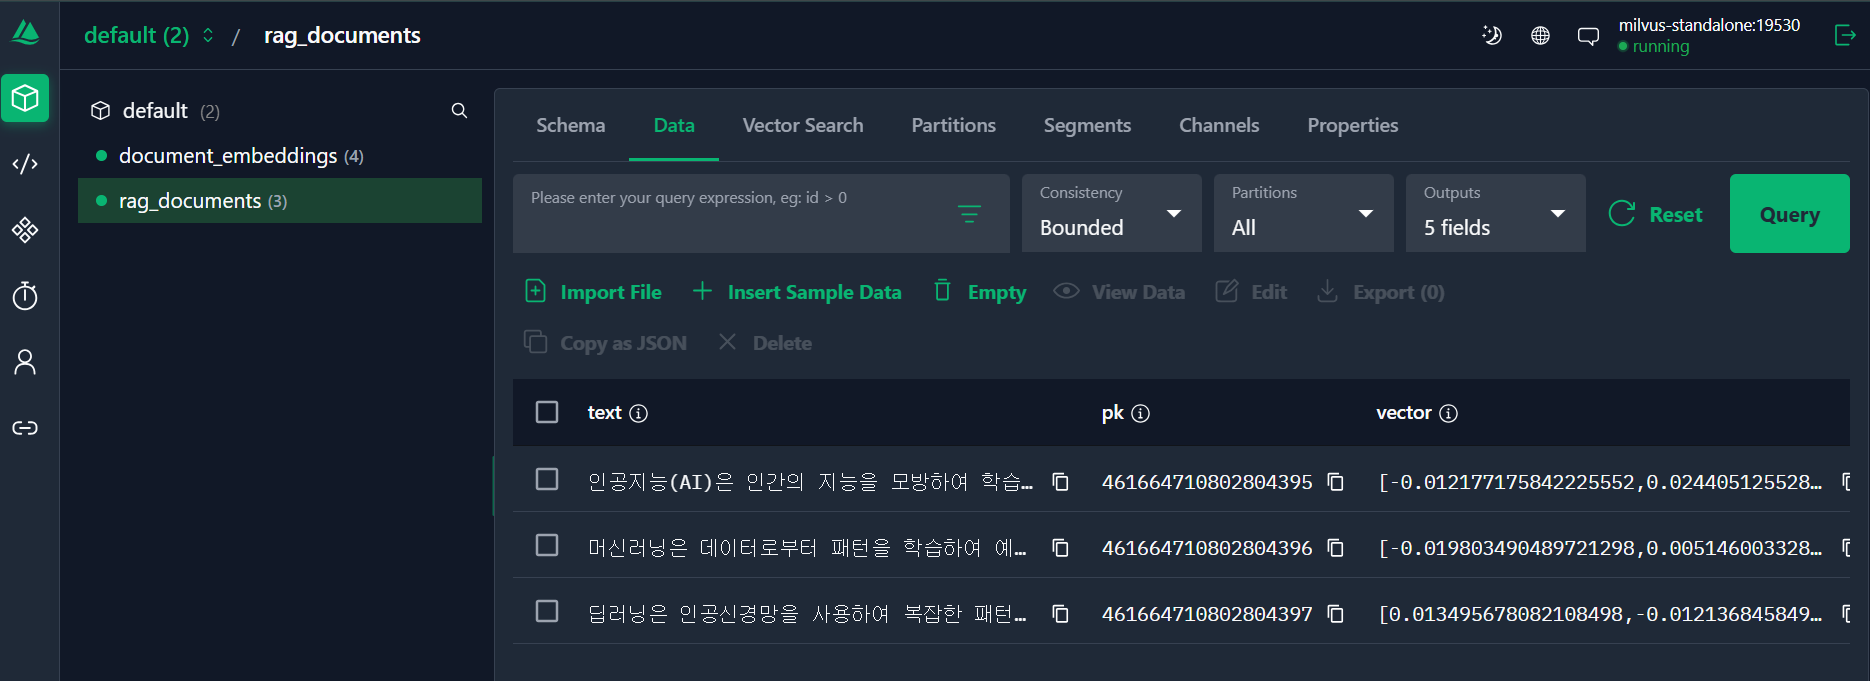

In [15]:
# 유사 문서 검색
query = "인공신경망에 대해 알려주세요"
results = vectorstore.similarity_search(query, k=2)

print(f"쿼리: {query}")
print("\n검색 결과:")
for i, doc in enumerate(results):
    print(f"{i+1}. {doc.page_content}")
    print(f"   메타데이터: {doc.metadata}")


쿼리: 인공신경망에 대해 알려주세요

검색 결과:
1. 딥러닝은 인공신경망을 사용하여 복잡한 패턴을 학습하는 머신러닝의 한 분야입니다.
   메타데이터: {'topic': 'DL', 'pk': 462700432930378759, 'source': 'dl_intro.txt'}
2. 머신러닝은 데이터로부터 패턴을 학습하여 예측이나 분류를 수행하는 AI의 한 분야입니다.
   메타데이터: {'topic': 'ML', 'pk': 462700432930378758, 'source': 'ml_intro.txt'}


### 4.3 RAG 체인 구성


In [16]:
from langchain_ollama.chat_models import ChatOllama 

# Ollama를 통해 로컬에서 실행되는 LLM(대규모 언어 모델) 초기화
llm = ChatOllama(
    model="gemma3:4b",        # Gemma3 4B 모델 사용 (40억 개의 파라미터)
    temperature=0.1,          # 생성 다양성 조절 (낮을수록 일관된 답변)
    top_p=1.0,                # 누적 확률 기반 샘플링 (1.0 = 모든 토큰 고려)
    num_predict=256,          # 생성할 최대 토큰 수
    keep_alive="5m"           # 모델을 메모리에 유지할 시간 (5분)
)

In [17]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

# VectorStore를 Retriever로 변환
# Retriever: 질문을 받아 관련 문서를 검색하는 인터페이스
retriever = vectorstore.as_retriever(
    # search_kwargs: 검색 시 사용할 파라미터
    # k=2: 가장 유사한 상위 2개 문서만 반환
    search_kwargs={"k": 2}
)

# 프롬프트 템플릿 정의
# RAG에서 LLM에게 컨텍스트(검색된 문서)와 질문을 함께 전달하기 위한 템플릿
prompt = ChatPromptTemplate.from_template("""
    Answer the question based on the context:

    <context>
    {context}
    </context>

    Question: {question}
""")

# 검색된 Document 객체들을 문자열로 변환하는 헬퍼 함수
# LLM은 텍스트만 이해하므로 Document 객체의 내용을 추출
def format_docs(docs):
    # 각 문서의 page_content를 개행으로 구분하여 하나의 문자열로 결합
    return "\n\n".join(doc.page_content for doc in docs)

# LCEL(LangChain Expression Language) 방식으로 RAG 체인 구성
# 파이프(|) 연산자로 각 단계를 연결
qa_chain = (
    # 첫 번째 단계: 입력 데이터 준비
    {
        # context: 질문 -> retriever로 검색 -> format_docs로 문자열 변환
        "context": retriever | format_docs,
        # question: 입력 질문을 그대로 전달 (RunnablePassthrough)
        "question": RunnablePassthrough()
    }
    # 두 번째 단계: 프롬프트 템플릿에 context와 question 삽입
    | prompt
    # 세 번째 단계: LLM에 프롬프트 전달하여 답변 생성
    | llm
    # 네 번째 단계: LLM 출력을 문자열로 파싱
    | StrOutputParser()
)


In [18]:
# 질문 답변 실행
question = "머신러닝과 딥러닝의 차이점은 무엇인가요?"

# LCEL 체인에 질문을 문자열로 전달
answer = qa_chain.invoke(question)

print(f"질문: {question}")
print(f"답변: {answer}")


질문: 머신러닝과 딥러닝의 차이점은 무엇인가요?
답변: 머신러닝은 데이터로부터 패턴을 학습하여 예측이나 분류를 수행하는 AI의 한 분야이고, 딥러닝은 인공신경망을 사용하여 복잡한 패턴을 학습하는 머신러닝의 한 분야입니다. 즉, 딥러닝은 머신러닝의 한 종류입니다.


## 5. 고급 기능 및 최적화

### 5.1 다양한 인덱스 타입 비교


In [19]:
# HNSW (Hierarchical Navigable Small World) 인덱스 파라미터
# 특징: 빠른 검색 속도와 높은 정확도를 동시에 제공하는 그래프 기반 인덱스
# 용도: 대규모 데이터에서 고성능 검색이 필요한 경우 (프로덕션 환경에 적합)
hnsw_params = {
    "metric_type": "L2",        # L2 거리 메트릭 사용
    "index_type": "HNSW",       # HNSW 인덱스 타입
    "params": {
        # M: 각 노드의 최대 연결 수 (클수록 정확도 높지만 메모리 사용량 증가)
        "M": 16,
        # efConstruction: 인덱스 구축 시 탐색 범위 (클수록 정확도 높지만 구축 시간 증가)
        "efConstruction": 200
    }
}

In [20]:
# IVF_SQ8 (Inverted File with Scalar Quantization) 인덱스 파라미터
# 특징: 벡터를 8비트로 양자화하여 메모리 사용량을 크게 줄임 (약 75% 감소)
# 용도: 메모리 제약이 있는 환경에서 대용량 데이터 처리 시 사용
# 트레이드오프: 메모리 절약 대신 약간의 정확도 손실
ivf_sq8_params = {
    "metric_type": "L2",        # L2 거리 메트릭 사용
    "index_type": "IVF_SQ8",    # IVF + 8비트 양자화 인덱스
    "params": {
        # nlist: 클러스터 수 (IVF_FLAT과 동일)
        "nlist": 1024
    }
}

In [21]:
# ANNOY (Approximate Nearest Neighbors Oh Yeah) 인덱스 파라미터
# 특징: 트리 기반 근사 검색 알고리즘으로 메모리 효율적이고 빠름
# 용도: 정확도보다 속도가 중요한 경우, 메모리가 제한적인 환경
# 장점: 낮은 메모리 사용, 빠른 검색 속도
# 단점: 근사 검색이므로 정확도가 다소 낮을 수 있음
annoy_params = {
    "metric_type": "L2",        # L2 거리 메트릭 사용
    "index_type": "ANNOY",      # ANNOY 인덱스 타입
    "params": {
        # n_trees: 생성할 트리 개수 (많을수록 정확도는 높지만 메모리와 구축 시간 증가)
        "n_trees": 100
    }
}

### 5.2 하이브리드 검색 (벡터 + 키워드)


In [22]:
# 하이브리드 검색 구현 함수
# 하이브리드 검색: 벡터 검색(의미 기반)과 키워드 검색(텍스트 매칭)을 결합
# 목적: 벡터 유사도가 높으면서도 특정 키워드를 포함하는 결과 찾기
def hybrid_search(collection, query_vector, keyword_filter, top_k=5):
    # 1단계: 벡터 유사도 검색 수행
    # 의미적으로 유사한 문서들을 먼저 찾음
    vector_results = collection.search(
        data=[query_vector],           # 검색 쿼리 벡터
        anns_field="embedding",        # 임베딩 필드에서 검색
        param=annoy_params,            # ANNOY 인덱스 파라미터 사용
        limit=top_k,                   # 상위 k개 결과 반환
        output_fields=["text", "id"]   # text와 id 필드를 함께 반환
    )
    
    # 2단계: 키워드 필터링 적용
    # 벡터 검색 결과 중에서 특정 키워드를 포함하는 문서만 필터링
    # 주의: 실제 프로덕션에서는 더 정교한 필터링 로직 사용 (정규표현식, 형태소 분석 등)
    filtered_results = []
    for result in vector_results[0]:
        # 대소문자 구분 없이 키워드가 텍스트에 포함되어 있는지 확인
        if keyword_filter.lower() in result.entity.get('text', '').lower():
            filtered_results.append(result)
    
    return filtered_results


In [23]:
# 하이브리드 검색 예제
keyword = "인공지능"
query_vector = embeddings_ollama.embed_query(keyword)

hybrid_results = hybrid_search(collection, query_vector, keyword, top_k=3)

print(f"하이브리드 검색 결과 (키워드: '{keyword}'):")
for i, result in enumerate(hybrid_results):
    print(f"{i+1}. {result.entity.get('text')}")
    print(f"   거리: {result.distance:.4f}")


하이브리드 검색 결과 (키워드: '인공지능'):
1. 인공지능은 컴퓨터 과학의 한 분야입니다.
   거리: 1.1343


### 5.3 성능 모니터링 및 최적화


In [24]:
import time

# 벡터 검색 성능을 측정하는 함수
# 목적: 인덱스 최적화, 파라미터 튜닝, 시스템 성능 평가
def measure_search_performance(collection, query_vector, iterations=100):
    # 컬렉션을 메모리에 로드 (검색 전 필수)
    collection.load()
    
    # 성능 측정 시작 시간 기록
    start_time = time.time()
    
    # 동일한 검색을 여러 번 반복하여 평균 성능 측정
    # iterations 만큼 반복하여 안정적인 성능 지표 확보
    for _ in range(iterations):
        # 벡터 검색 실행
        results = collection.search(
            data=[query_vector],        # 검색 쿼리 벡터
            anns_field="embedding",     # 임베딩 필드에서 검색
            # 검색 파라미터: L2 거리, nprobe=10
            param={"metric_type": "L2", "params": {"nprobe": 10}},
            limit=5                     # 상위 5개 결과만 반환
        )
    
    # 성능 측정 종료 시간 기록
    end_time = time.time()
    
    # 평균 검색 시간 계산 (초 단위)
    avg_time = (end_time - start_time) / iterations
    
    # 결과 출력
    # ms(밀리초) 단위로 변환하여 출력 (1초 = 1000ms)
    print(f"평균 검색 시간: {avg_time*1000:.2f}ms")
    
    # QPS (Queries Per Second): 초당 처리 가능한 검색 횟수
    # 시스템의 처리량(throughput)을 나타내는 중요한 지표
    print(f"초당 검색 횟수: {1/avg_time:.2f} QPS")
    
    return avg_time


In [25]:
# 성능 측정
keyword = "인공지능"
query_vector = embeddings_ollama.embed_query(keyword)
measure_search_performance(collection, query_vector, iterations=50)


평균 검색 시간: 1.95ms
초당 검색 횟수: 513.12 QPS


0.001948843002319336